In [ ]:
# Run the code below to install dependencies, if not using the course's pixi environment
# %pip install matplotlib numpy pandas seaborn tqdm

In [72]:
import functools
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm


# Micro-Benchmarking and Higher-Order Functions: Measuring How Code Scales

Performance work is not only about finding single bottlenecks; rather, it is about understanding how runtime grows as input size increases. Some code looks fast at small scales but collapses as data grows. Other code has hidden structural advantages that only become visible when you examine scaling behavior carefully. This notebook focuses on measuring and visualizing performance growth, not guessing at it.

The notebook is organized in three parts:
  1. First, we  will build the conceptual foundation for benchmarking by learning how to pass functions into other functions, as part of our goals to build our coding skills and understand a method by which we can call other people's functions that can call our own functions.
  2. Second, we will run structured micro-benchmarks across increasing input sizes and visualize how different implementations scale. 
  3. Finally, we will dig beneath surface timing results to understand why certain patterns emerge, connecting observed runtime behavior to memory allocation strategies and hardware-level effects.

## Utility Functions

Before starting the exercises, please run the code below, which provides some utilities helpful for the exercises:

In [ ]:

import random
from timeit import Timer


def _benchmarks_to_dataframe(*name_data_pairs):
    from itertools import batched
    data = dict(batched(name_data_pairs, 2))
    df = pd.DataFrame(data)
    df_long = df.melt(var_name='level', value_name='time')
    return df_long
    

def _run_benchmarks(levels, *functions, repeats=7, loops=200, shuffle=True):
    dfs = []
    levels_all = list(levels) * repeats
    benchmarks_all = [(function, level) for function in functions for level in levels_all]

    # if shuffle is true, Run the benchmarks in random order.
    if shuffle:
        random.shuffle(benchmarks_all)

    for function, level in tqdm(benchmarks_all):
        timer = Timer(functools.partial(function, level))
        if loops is None:
            loops, _ = timer.autorange()  # Auto-estimate the number of loops 
        timings = timer.repeat(repeat=1, number=loops)
        timings_corrected = [t / loops for t in timings]
        df = _benchmarks_to_dataframe(level, timings_corrected)
        df.insert(0, 'method', function.__name__)
        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)
    return df


class utils:
    run_benchmarks = _run_benchmarks


---

## Section 1: Creating Functions that Take Other Functions as Input

Benchmarking requires flexibility: we want to test many implementations with the same measurement logic. That means our benchmarking tools must accept functions as arguments. This section builds that conceptual foundation. You will work with higher-order functions and partial functions so that you can generate configurable behaviors from simple building blocks. The goal is not abstraction for its own sake — it is to make performance experiments composable and systematic.


### Exercises

These exercises reinforce two core ideas:
  1. Functions are first-class objects in Python.
  2. Behavior can be parameterized cleanly using functools.partial.

We will first define simple arithmetic functions, then create specialized versions by partially binding arguments. Finally, we will write wrapper functions that accept other functions as input — enabling logging and benchmarking behavior without modifying the original functions. This separation of concerns is essential for clean experimental design.

**Example**: Define a function called `add()` that passes the tests below.

In [74]:
def add(x, y):
    return x + y

assert add(3, 5) == 8
assert add(5, 5) == 10
assert add(10, 20) == 30
print('✅ All Tests Passed!')

✅ All Tests Passed!


**Example**: Create a Partial Function called `add5` that uses the `add()` function to pass the tests below: 

In [73]:
add5 = functools.partial(add, 5)

In [75]:
assert add5(10) == 15
assert add5(2) == 7
print('✅ All Tests Passed!')

✅ All Tests Passed!


**Exercise**: Define a function called `mul()` that passes the tests below.

In [70]:
def mul(x, y):
    return x * y

In [71]:
assert mul(3, 5) == 15
assert mul(5, 5) == 25
assert mul(10, 20) == 200
print('✅ All Tests Passed!')

✅ All Tests Passed!


**Exercise**: Create a Partial Function called `mul2` that uses the `mul()` function to pass the tests below: 

In [76]:
mul2 = functools.partial(mul, 2)

In [77]:
assert mul2(3) == 6
assert mul2(10) == 20
print('✅ All Tests Passed!')

✅ All Tests Passed!


**Exercise**: Create a Partial Function called `ten` that uses the `mul()` function to pass the tests below: 

In [78]:
ten = functools.partial(mul, 2, 5)

In [79]:
assert ten() == 10
print('✅ All Tests Passed!')

✅ All Tests Passed!


**Example**: You can also define functions as inputs to other functions!  Let's try it:

Make a `loud(fun, x, y)` function that does the following:
  1. prints "starting!"
  2. calls any function passed to it with `x` and `y` as inputs (i.e. `fun(x, y)`)
  3. prints "done!"
  4. returns the result of the function.

Test it out with `loud(add, 3, 4)`

In [84]:
def loud(fun, x, y):
    print('starting!')
    result = fun(x, y)
    print('done!')
    return result

loud(add, 3, 4)

starting!
done!


7

**Exercise**: Make a `benchmark(fun, x, y)` function that does the following:
  1. measures the current time `t0 = time.perf_counter()`
  2. calls any function passed to it with `x` and `y` as inputs (i.e. `fun(x, y)`)
  3. measures the current time `t1 = time.perf_counter()`
  4. returns the time passed between `t1` and `t0`.

Test it out with `benchmark(mul, 3, 4)`


In [85]:
def benchmark(fun, x, y):
    t0 = time.perf_counter()
    fun(x, y)
    t1 = time.perf_counter()
    return t1 - t0

benchmark(mul, 3, 4)

9.99999429041054e-07

This approach of passing functions into other functions makes it possible to have genealizable code that does a specific job in a wide variety of contexts.

---

## Section 2: Micro-Benchmarking: How does Code Scale?

Single timing measurements are deceptive. What matters is how runtime changes as input size increases. Micro-benchmarking measures small, isolated functions across multiple problem sizes to reveal scaling patterns. By plotting runtime against input size, we move from anecdotal impressions (“this feels slow”) to structural insight (“this grows quadratically”).

In this section, we will compare multiple ways of building lists and arrays. Some approaches appear equivalent at small sizes but diverge dramatically as inputs grow. The focus is not just on which method is faster — it is on identifying the shape of growth: linear, quadratic, or worse.


| Code | Description |
| :-- | :-- |
| **`df = utils.run_benchmarks([1, 2], my_function)`** | Returns a dataframe with benchmark runs of `my_function()` on each the parameters in the list |
| **`df = utils.run_benchmarks([1, 2], fun1, fun2)`** | Returns a dataframe with benchmark runs of `fun1()` and `fun2()` on each the parameters in the list |
| --- | --- |
| **`sns.lineplot(data=df, x='level', y='time')`** | Make a line plot from the `df` dataframe. The 'level' column's data should be used for the x-axis, and he `time` column for the y-axis. |
| **`ssn.lineplot(..., hue='method')`** | For each unique value in the 'method' column, make a new color'd line.  Show the value in a legend. |
| **`ssn.lineplot(..., estimator='min')`** | Fit the line to the minimum value, not the mean. |
| **`sns.lineplot(..., linestyle='dotted', marker='o')`** | Make a dotted line with circle markders where measurments took place |

### Exercises

**Example**: Write a function that creates an empty list, then appends another value to the list in a loop by concatenating to it with the `+` operator `n` times.  Benchmark the function using `utils.run_benchmarks()` with different levels to see how this function scales with `n`.  Use `sns.lineplot()` to visualize the benchmark.

  - Initialize a New List: `data = []`
  - Append a new value: `data = data + [value]`

100%|██████████| 42/42 [00:01<00:00, 30.80it/s]


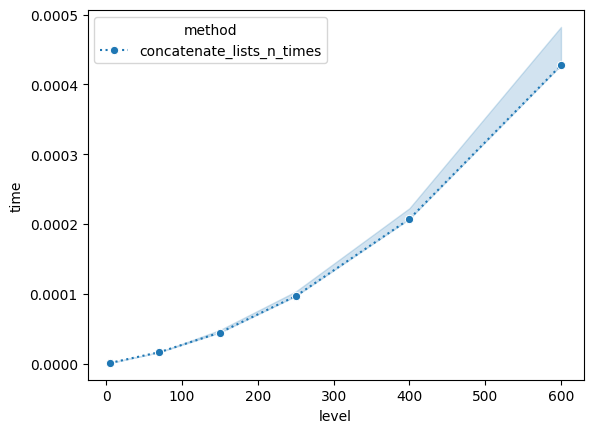

In [61]:
def concatenate_lists_n_times(n):
    data = []
    for i in range(n):
        data = data + [i]
    return data

levels = [5, 70, 150, 250, 400, 600]  # or np.geomspace(5, 900, 7).astype(int) for well-spaced levels
df = utils.run_benchmarks(levels, concatenate_lists_n_times, )
sns.lineplot(data=df, x='level', y='time', hue='method', estimator='min', linestyle='dotted', marker='o');

**Exercise**: Write a function that creates an empty list, then appends another value to the list in a loop by using the list's `append()` method `n` times.  Benchmark the function using `utils.run_benchmarks()` with different levels to see how this function scales with `n`.  Use `sns.lineplot()` to visualize the benchmark.

  - Initialize a New List: `data = []`
  - Append a new value: `data.append()`

100%|██████████| 63/63 [00:00<00:00, 102.53it/s]


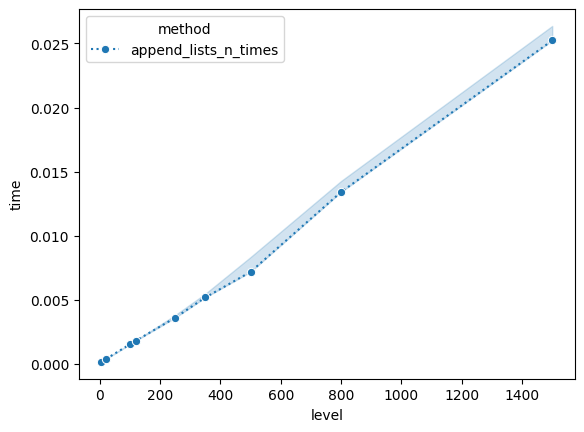

In [ ]:
def append_lists_n_times(n):
    data = []
    for i in range(n):
        data.append(i)
    return data

levels = [5, 70, 150, 250, 400, 600]  # or np.geomspace(5, 900, 7).astype(int) for well-spaced levels
df = utils.run_benchmarks(levels, append_lists_n_times)
sns.lineplot(data=df, x='level', y='time', hue='method', estimator='min', linestyle='dotted', marker='o');

**Exercise**: Write a function that creates an empty Numpy array, then appends another value to the array in a loop by using the Numpy's `append()` function `n` times.  Benchmark the function using `utils.run_benchmarks()` with different levels to see how this function scales with `n`.  Use `sns.lineplot()` to visualize the benchmark.

  - Initialize a New Numpy Array: `data = np.array([])`
  - Append a new value: `data = np.append(data, [value])`

100%|██████████| 35/35 [00:04<00:00,  8.15it/s]


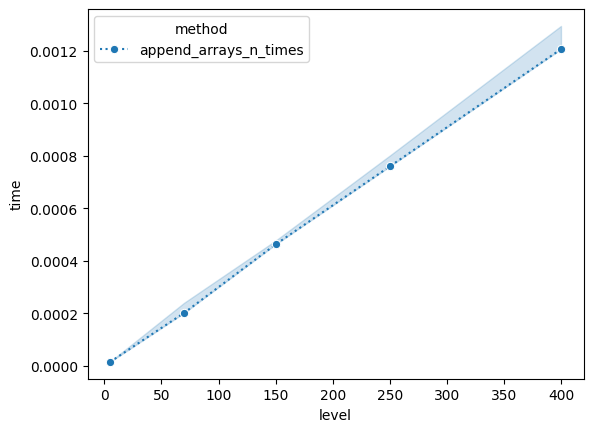

In [ ]:
def append_arrays_n_times(n):
    data = np.array([])
    for i in range(n):
        data = np.append(data, [i])
    return data

levels = [5, 70, 150, 250, 400, 600]  # or np.geomspace(5, 900, 7).astype(int) for well-spaced levels
df = utils.run_benchmarks(levels, append_arrays_n_times)
sns.lineplot(data=df, x='level', y='time', hue='method', estimator='min', linestyle='dotted', marker='o');

**Exercise**: Write a function that creates an empty Numpy array that is already **n** values big, then sequencially replaces each value in the array in a loop by using the indexing.  Benchmark the function using `utils.run_benchmarks()` with different levels to see how this function scales with `n`.  Use `sns.lineplot()` to visualize the benchmark.

  - Initialize a New Numpy Array with N values: `data = np.empty(n)`
  - Replace value at a given index with a new value: `data[idx] = value`

100%|██████████| 63/63 [00:00<00:00, 75.25it/s]


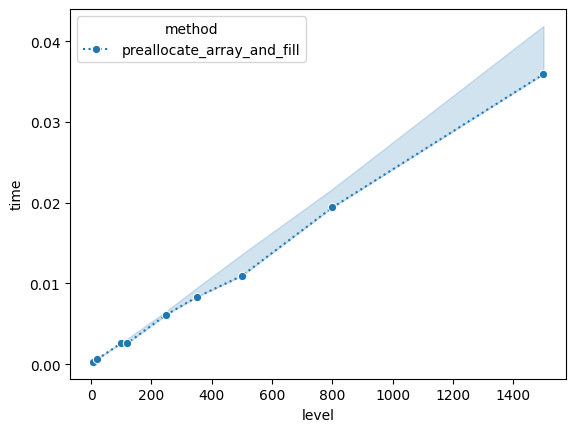

In [ ]:
def preallocate_array_and_fill(n):
    data = np.empty(n)
    for i in range(n):
        data[i] = i
    return data

levels = [5, 70, 150, 250, 400, 600]  # or np.geomspace(5, 900, 7).astype(int) for well-spaced levels
df = utils.run_benchmarks(levels, preallocate_array_and_fill)
sns.lineplot(data=df, x='level', y='time', hue='method', estimator='min', linestyle='dotted', marker='o');

**Example**: Which of the two methods for creating lists done above is most performant: concatenating or appending?  Run the benchmarks again for both the functions created, and plot the lines against each other.  (Tip: `utils.run_benchmarks()` can run on multiple functions all in one go: `df = utils.run_benchmarks(levels, fun1, fun2)`)

100%|██████████| 112/112 [00:01<00:00, 56.64it/s]


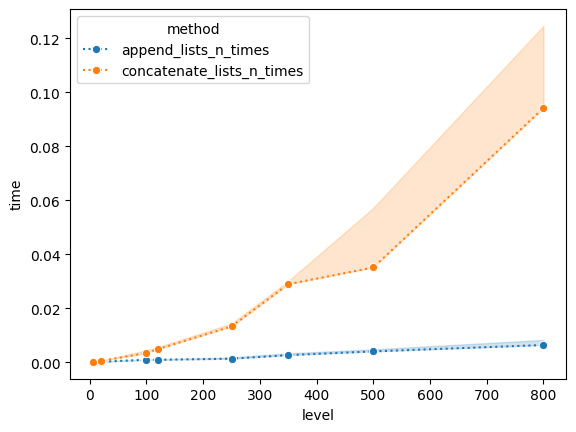

In [ ]:
levels = [5, 70, 150, 250, 400, 600]  # or np.geomspace(5, 900, 7).astype(int) for well-spaced levels
df = utils.run_benchmarks(levels, concatenate_lists_n_times, append_lists_n_times)
sns.lineplot(data=df, x='level', y='time', hue='method', estimator='min', linestyle='dotted', marker='o');


**Example**: Plot the Comparison again, but this time with `log-log` scaling using the `plt.loglog()` functions, so that both the small and large values are visible:

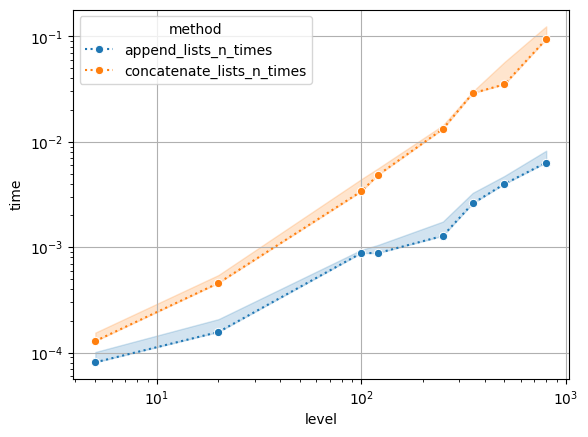

In [42]:
sns.lineplot(data=df, x='level', y='time', hue='method', estimator='min', linestyle='dotted', marker='o');
plt.loglog();
plt.grid()

**Exercise**: Which of the two methods for creating arrays done above is most performant: appending or pre-allocating?  Run the benchmarks again for both the functions created, and plot the lines against each other.  (Tip: `utils.run_benchmarks()` can run on multiple functions all in one go: `df = utils.run_benchmarks(levels, fun1, fun2)`)

100%|██████████| 140/140 [00:34<00:00,  4.08it/s]


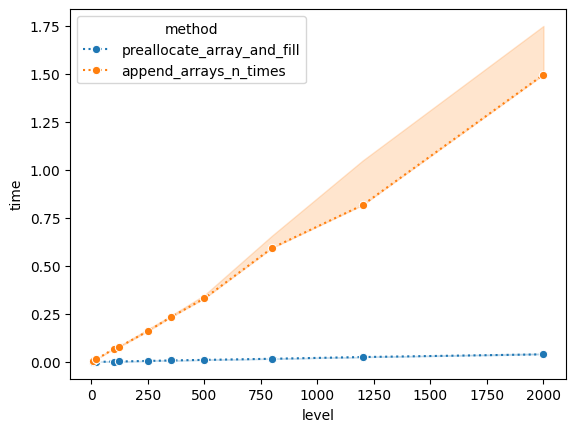

In [ ]:
levels = [5, 70, 150, 250, 400, 600]  # or np.geomspace(5, 900, 7).astype(int) for well-spaced levels
df = utils.run_benchmarks(levels, append_arrays_n_times, preallocate_array_and_fill)
sns.lineplot(data=df, x='level', y='time', hue='method', estimator='min', linestyle='dotted', marker='o');

**Exercise**: Plot the Comparison again, but this time with `log-log` scaling using the `plt.loglog()` functions, so that both the small and large values are visible:

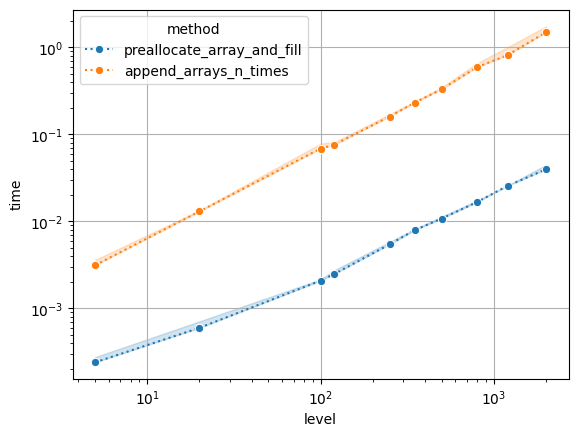

In [40]:
sns.lineplot(data=df, x='level', y='time', hue='method', estimator='min', linestyle='dotted', marker='o');
plt.loglog();
plt.grid()

---

## Section 3: "Why" Matters. Things are not simple when you dig under the surface.

Benchmark plots show what happens. They rarely explain why. Two functions with similar average timings may behave very differently internally. Variance patterns — not just means — can reveal structural behavior such as memory reallocation, copying, or cache effects.

This section moves from macro-level timing curves to fine-grained measurement of individual operations. By recording the timing of each append operation, you can observe allocation patterns directly. 

### Exercises

**Demo**: Recording the time for each `list.append()` call reveals some interesting patterns: 

   1. Most of the `append()` calls run very quickly, and only some run slowly.
   2. The slow `append()` calls are regularly-spaced out, with increasing spacing as the list grows.
   3. The slow `append()` calls get slower as the list gets larger.

This is because Python lists **automatically pre-allocate** extra memory, so they don't have to ask the operating system for more memory every time `append()` is called.  Only when the list runs out of memory does it ask for more memory, and the because the required memory is more over time, the request takes longer to complete.  This makes lists very fast at `append()` operations.

100%|██████████| 5000000/5000000 [00:03<00:00, 1517915.57it/s]


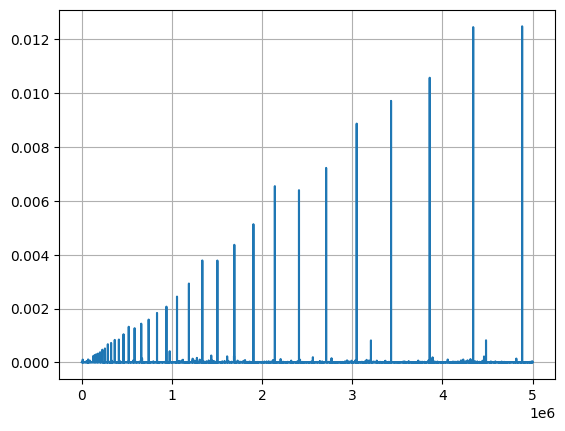

In [ ]:
data = []  # Initialize Data
timings = []
for i in tqdm(range(5_000_000)):
    t0 = time.perf_counter()
    data.append(i)  # Append to Data
    t1 = time.perf_counter()
    timings.append(t1 - t0)


plt.plot(timings);
plt.grid();


***Demo**: Recording the time for each `np.append()` call reveals some other interesting patterns: 

   1. There is high variance in the time, and there doesn't seem to be a clear pattern to it.
   2. The minimum calls time seems to grow over time
   3. There is a sharp jump at about 130,000, from where it takes even more time for each call.

This is because Numpy arrays do not preallocate  extra memory, so they have to ask the operating system for more memory every time `append()` is called, and copy all of the data from the previous array's memory location into the new array's memory location.  The more memory that needs to be copied, the larger the memory cache that's needed to fit the data; on my laptop, the L2 cache is only 1MB big (130,000 values * 64 bits per value = 1.04 MB), so the jump is showing where the OS is no longer able to use L2 cache and must use L3 cache, which is 3-5 times slower than L2.

  0%|          | 0/250000 [00:00<?, ?it/s]

100%|██████████| 250000/250000 [01:19<00:00, 3163.53it/s] 


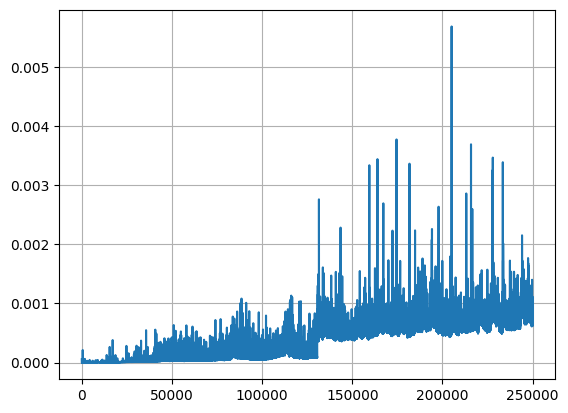

In [ ]:
data = np.array([])   # Initialize Data
ts = []
for i in tqdm(range(250_000)):
    t0 = time.perf_counter()
    data = np.append(data, [i])   # Append to Data
    t1 = time.perf_counter()
    ts.append(t1 - t0)


plt.plot(ts,);
plt.grid();


**Exercise**: Are Python `dict`s fast to append, like lists, or do they need to find memory like arrays?  Copy from the code above and replace the relevant parts with a dictionary

  - Initialize dict: `data = {}`
  - Append to dict: `data[i] = i`

100%|██████████| 5000000/5000000 [00:04<00:00, 1141413.68it/s]


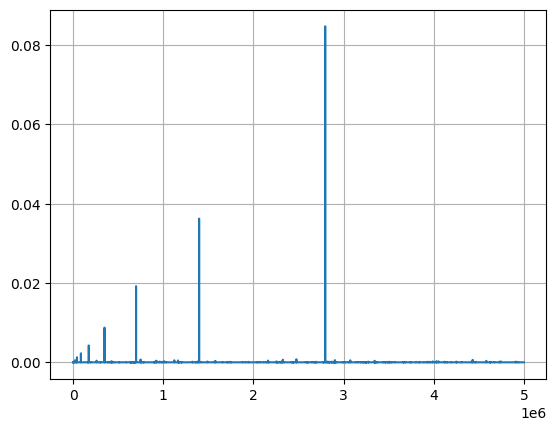

In [ ]:
data = {}  # Initialize Data
timings = []
for i in tqdm(range(5_000_000)):
    t0 = time.perf_counter()
    data[i] = i   # Append to Data
    t1 = time.perf_counter()
    timings.append(t1 - t0)


plt.plot(timings);
plt.grid();


**Exercise**: Are Python `tuples`s fast to append, like lists, or do they need to find memory like arrays?  Copy from the code above and replace the relevant parts with a tuple.

  - Initialize tuple: `data = ()`
  - Append to tuple: `data = data + (i,)`

100%|██████████| 300000/300000 [10:38<00:00, 470.10it/s] 


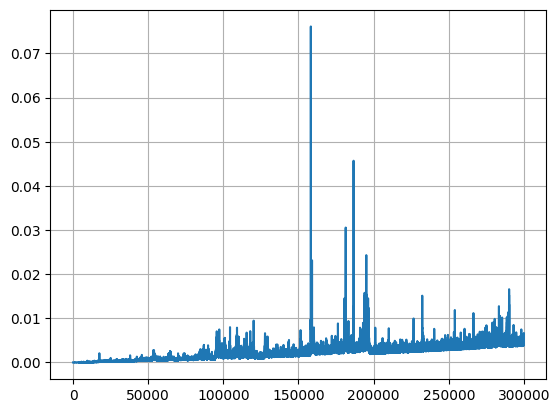

In [196]:
data = ()  # Initialize Data
timings = []
for i in tqdm(range(300_000)):
    t0 = time.perf_counter()
    data = data + (i,)  # Append to Data
    t1 = time.perf_counter()
    timings.append(t1 - t0)


plt.plot(timings);
plt.grid();


In [ ]:
for 